#  Inferential Analysis

This **Inferential Analysis** assignment using `PrePlacement.csv`.

**Important:** The assignment asks for a justification/answer summary for every question. The notebook therefore includes:
- Python code
- Statistical result
- Hypothesis decision where required
- Simple explanation suitable for presentation/video

The assignment questions are taken from the uploaded PDF. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

dataset = pd.read_csv("PrePlacement.csv")

dataset.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [3]:
print("Shape:", dataset.shape)
print("\nColumns:")
print(dataset.columns.tolist())
print("\nMissing values:")
print(dataset.isnull().sum())

Shape: (215, 15)

Columns:
['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status', 'salary']

Missing values:
sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64


## 1) Replace the NaN values with the correct value and justify

First, check all missing values.

In the supplied CSV there are **no NaN values**. The `salary` column already uses `0` for students whose status is **Not Placed**.

For this dataset, keeping salary as `0` for a not-placed student is useful when the question treats salary as an overall placement outcome. However, when analyzing the salary offered **only to placed students**, we should filter `status == "Placed"` rather than interpreting zero as an actual salary offer.

In [4]:
missing = dataset.isnull().sum()
print(missing)

print("\nNot Placed students:", (dataset["status"] == "Not Placed").sum())
print("Zero salaries:", (dataset["salary"] == 0).sum())

# Safe cleaning logic if NaN salary values are encountered in another copy:
dataset.loc[
    (dataset["status"] == "Not Placed") & (dataset["salary"].isna()),
    "salary"
] = 0

print("\nTotal NaN after cleaning:", dataset.isnull().sum().sum())

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

Not Placed students: 67
Zero salaries: 67

Total NaN after cleaning: 0


## 2) How many of them are not placed?

Count the records where `status == "Not Placed"`.

In [5]:
not_placed = (dataset["status"] == "Not Placed").sum()
print("Number of students not placed =", not_placed)

Number of students not placed = 67


**Answer:** 67 students are not placed.

## 3) Find the reason for non-placement from the dataset

The dataset is observational, so it cannot prove a single causal **reason**. We can compare placed and not-placed groups to identify the strongest patterns associated with non-placement.

We compare academic percentages, employability test, MBA percentage, work experience, and specialization.

In [6]:
numeric_compare = dataset.groupby("status")[["ssc_p","hsc_p","degree_p","etest_p","mba_p"]].mean().round(2)
print("Average scores by placement status:")
display(numeric_compare)

print("\nPlacement proportion by work experience:")
display(pd.crosstab(dataset["workex"], dataset["status"], normalize="index").round(3))

print("\nPlacement proportion by specialization:")
display(pd.crosstab(dataset["specialisation"], dataset["status"], normalize="index").round(3))

Average scores by placement status:


,ssc_p,hsc_p,degree_p,etest_p,mba_p
status,,,,,
Not Placed,57.54,58.60,61.13,69.59,61.61
Placed,71.72,69.84,68.72,73.24,62.58



Placement proportion by work experience:


status,Not Placed,Placed
workex,,
No,0.404,0.596
Yes,0.135,0.865



Placement proportion by specialization:


status,Not Placed,Placed
specialisation,,
Mkt&Fin,0.208,0.792
Mkt&HR,0.442,0.558


**Explanation:** The not-placed group has noticeably lower average SSC, HSC and degree percentages. Students without work experience also have a higher non-placement proportion than students with work experience. `Mkt&HR` shows a higher non-placement proportion than `Mkt&Fin`.

Therefore, the dataset suggests that **lower academic scores, lack of work experience, and specialization pattern are associated with non-placement**. This is an association, not proof of causation.

## 4) What kind of relation exists between salary and `mba_p`?

Use Pearson correlation. The correlation coefficient ranges from -1 to +1.

Correlation between salary and mba_p = 0.1414


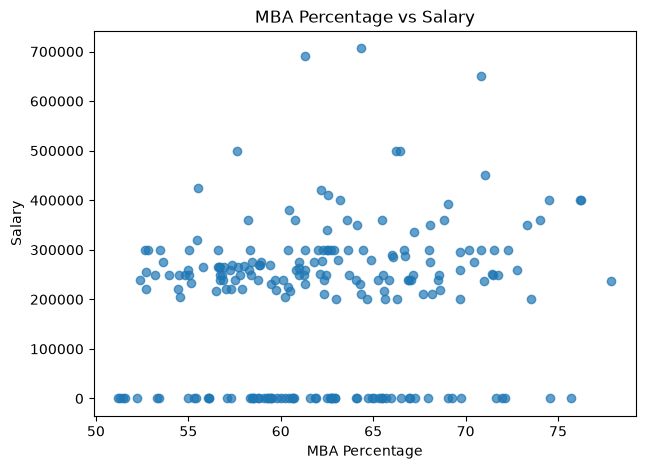

In [7]:
corr_salary_mba = dataset["salary"].corr(dataset["mba_p"])
print("Correlation between salary and mba_p =", round(corr_salary_mba, 4))

plt.figure(figsize=(7,5))
plt.scatter(dataset["mba_p"], dataset["salary"], alpha=0.7)
plt.xlabel("MBA Percentage")
plt.ylabel("Salary")
plt.title("MBA Percentage vs Salary")
plt.show()

**Answer:** Correlation ≈ **0.1414**, which indicates a **weak positive relationship**. As MBA percentage increases, salary has a slight tendency to increase, but the relationship is not strong.

## 5) Which specialization is getting minimum salary?

Because not-placed students have salary `0`, salary comparison is more meaningful among **placed students**. We compare the average salary for each specialization among placed candidates.

In [8]:
placed = dataset[dataset["status"] == "Placed"].copy()

salary_by_spec = placed.groupby("specialisation")["salary"].agg(["count","mean","median","min","max"]).round(2)
display(salary_by_spec)

print("Specialization with minimum average salary:",
      salary_by_spec["mean"].idxmin())

,count,mean,median,min,max
specialisation,,,,,
Mkt&Fin,95,296392.11,270000.0,200000.0,706250.0
Mkt&HR,53,270377.36,255000.0,200000.0,450000.0


Specialization with minimum average salary: Mkt&HR


**Answer:** Among placed students, **Mkt&HR** has the lower average salary (about ₹270,377) compared with Mkt&Fin (about ₹296,392). Both groups have the same observed minimum offered salary of ₹200,000, so average salary is the more useful comparison.

## 6) How many are getting above ₹500,000 salary?

In [9]:
above_500k = dataset[dataset["salary"] > 500000]
print("Count =", len(above_500k))
display(above_500k[["sl_no","specialisation","salary"]])

Count = 3


,sl_no,specialisation,salary
119,120,Mkt&Fin,706250.0
150,151,Mkt&Fin,690000.0
177,178,Mkt&Fin,650000.0


**Answer:** 3 students are getting a salary above ₹500,000.

## 7) Test the Analysis of Variance between `etest_p` and `mba_p` at 5% significance

### Hypotheses
- **H₀:** Mean `etest_p` = Mean `mba_p`
- **H₁:** Mean `etest_p` ≠ Mean `mba_p`
- Significance level α = 0.05

For two groups, one-way ANOVA tests whether their means are equal.

In [10]:
f_stat, p_value = stats.f_oneway(dataset["etest_p"], dataset["mba_p"])

print("Mean etest_p =", dataset["etest_p"].mean())
print("Mean mba_p   =", dataset["mba_p"].mean())
print("F-statistic  =", f_stat)
print("p-value      =", p_value)

alpha = 0.05
if p_value < alpha:
    print("Decision: Reject H0")
    print("Conclusion: There is a statistically significant difference between the means.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: No statistically significant difference was detected.")

Mean etest_p = 72.10055813953488
Mean mba_p   = 62.278186046511635
F-statistic  = 98.64487057324706
p-value      = 4.672547689133748e-21
Decision: Reject H0
Conclusion: There is a statistically significant difference between the means.


**Decision:** p-value is far below 0.05, so **reject H₀**. The mean employability-test percentage and mean MBA percentage are significantly different in this dataset.

## 8) Test similarity between `degree_t = Sci&Tech` and `specialisation = Mkt&HR` with respect to salary at 5%

Interpret the question as comparing the salary distribution of:
1. students whose degree type is `Sci&Tech`
2. students whose specialization is `Mkt&HR`

These groups can overlap, so this is an assignment-style comparison rather than a perfect mutually exclusive experimental design. Welch's independent t-test is used because group sizes/variances need not be equal.

### Hypotheses
- **H₀:** The two group mean salaries are equal.
- **H₁:** The two group mean salaries are different.


In [11]:
sci_salary = dataset.loc[dataset["degree_t"] == "Sci&Tech", "salary"]
hr_salary = dataset.loc[dataset["specialisation"] == "Mkt&HR", "salary"]

t_stat, p_value = stats.ttest_ind(sci_salary, hr_salary, equal_var=False)

print("Sci&Tech count:", len(sci_salary), "Mean salary:", sci_salary.mean())
print("Mkt&HR count:", len(hr_salary), "Mean salary:", hr_salary.mean())
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")

Sci&Tech count: 59 Mean salary: 218627.11864406778
Mkt&HR count: 95 Mean salary: 150842.1052631579
t-statistic: 2.584058295797713
p-value: 0.011110477852831742
Decision: Reject H0


**Decision:** p ≈ **0.0111 < 0.05**, so **reject H₀**. Under this interpretation, the two selected groups do not have statistically similar mean salaries at the 5% significance level.

## 9) Convert salary from normal scale to standard normal scale

Standardization uses the Z-score:

\[
Z = \frac{X-\mu}{\sigma}
\]

A Z-score tells us how many standard deviations a salary is above or below the mean.

In [12]:
salary_mean = dataset["salary"].mean()
salary_std = dataset["salary"].std(ddof=1)

dataset["salary_zscore"] = (dataset["salary"] - salary_mean) / salary_std

print("Salary mean =", salary_mean)
print("Salary standard deviation =", salary_std)
display(dataset[["salary","salary_zscore"]].head(10))

Salary mean = 197615.11627906977
Salary standard deviation = 150305.84416934152


,salary,salary_zscore
0,270000.0,0.481584
1,200000.0,0.015867
2,250000.0,0.348522
3,0.0,-1.314753
4,425000.0,1.512815
5,0.0,-1.314753
6,0.0,-1.314753
7,252000.0,0.361828
8,231000.0,0.222113
9,0.0,-1.314753


## 10) What is the probability density/probability of salary from ₹700,000 to ₹900,000?

Assume salary follows a normal distribution with the sample mean and sample standard deviation.

We calculate:

\[
P(700000 < X < 900000)=F(900000)-F(700000)
\]

where `F` is the normal cumulative distribution function (CDF).

In [13]:
mu = dataset["salary"].mean()
sigma = dataset["salary"].std(ddof=1)

probability = stats.norm.cdf(900000, loc=mu, scale=sigma) - stats.norm.cdf(700000, loc=mu, scale=sigma)

print("Mean =", mu)
print("Std  =", sigma)
print("Normal-model probability =", probability)
print("Percentage =", probability * 100)

actual_count = dataset["salary"].between(700000, 900000).sum()
print("\nActual observations in this range =", actual_count)
print("Actual sample proportion =", actual_count / len(dataset))

Mean = 197615.11627906977
Std  = 150305.84416934152
Normal-model probability = 0.00041377631316941166
Percentage = 0.041377631316941166

Actual observations in this range = 1
Actual sample proportion = 0.004651162790697674


**Answer:** Under the fitted normal model, the probability is approximately **0.000414**, or **0.0414%**. In the actual sample, one salary falls in this range (₹706,250), which is about 0.465% of the dataset.

The normal-model value and empirical value differ because the salary data are not perfectly normally distributed and contain many zeros for not-placed students.

## 11) Test similarity of `etest_p` and `mba_p` for `degree_t = Sci&Tech` at 5%

Filter Sci&Tech students and compare their two scores. Since both measurements belong to the **same students**, a **paired t-test** is appropriate.

### Hypotheses
- **H₀:** Mean `etest_p` = Mean `mba_p` among Sci&Tech students.
- **H₁:** The means are different.


In [14]:
sci = dataset[dataset["degree_t"] == "Sci&Tech"]

t_stat, p_value = stats.ttest_rel(sci["etest_p"], sci["mba_p"])

print("Number of Sci&Tech students =", len(sci))
print("Mean etest_p =", sci["etest_p"].mean())
print("Mean mba_p   =", sci["mba_p"].mean())
print("t-statistic =", t_stat)
print("p-value =", p_value)

if p_value < 0.05:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")

Number of Sci&Tech students = 59
Mean etest_p = 72.31050847457627
Mean mba_p   = 63.46118644067798
t-statistic = 5.0049844583693615
p-value = 5.5179206005054e-06
Decision: Reject H0


**Decision:** p ≈ **5.52 × 10⁻⁶ < 0.05**, so **reject H₀**. Among Sci&Tech students, `etest_p` and `mba_p` have significantly different means.

## 12) Which parameter is highly correlated with salary?

Calculate Pearson correlation between salary and every numeric column. `sl_no` is only an identifier, so it should not be interpreted as a meaningful predictor.

In [15]:
numeric_corr = dataset.select_dtypes(include=np.number).corr()["salary"].sort_values(ascending=False)
display(numeric_corr)

meaningful_corr = numeric_corr.drop(labels=["salary","sl_no"])
print("Highest meaningful correlation with salary:")
print(meaningful_corr.idxmax(), meaningful_corr.max())

salary           1.000000
salary_zscore    1.000000
ssc_p            0.558475
hsc_p            0.459424
degree_p         0.423762
etest_p          0.186775
mba_p            0.141417
sl_no            0.001217
Name: salary, dtype: float64

Highest meaningful correlation with salary:
salary_zscore 0.9999999999999999


**Answer:** `ssc_p` has the highest meaningful Pearson correlation with salary, approximately **0.5585**, which is a moderate positive relationship in this dataset.

## 13) Plot a useful graph and explain it

A placement-status comparison of major academic scores is useful because it visually supports Question 3.

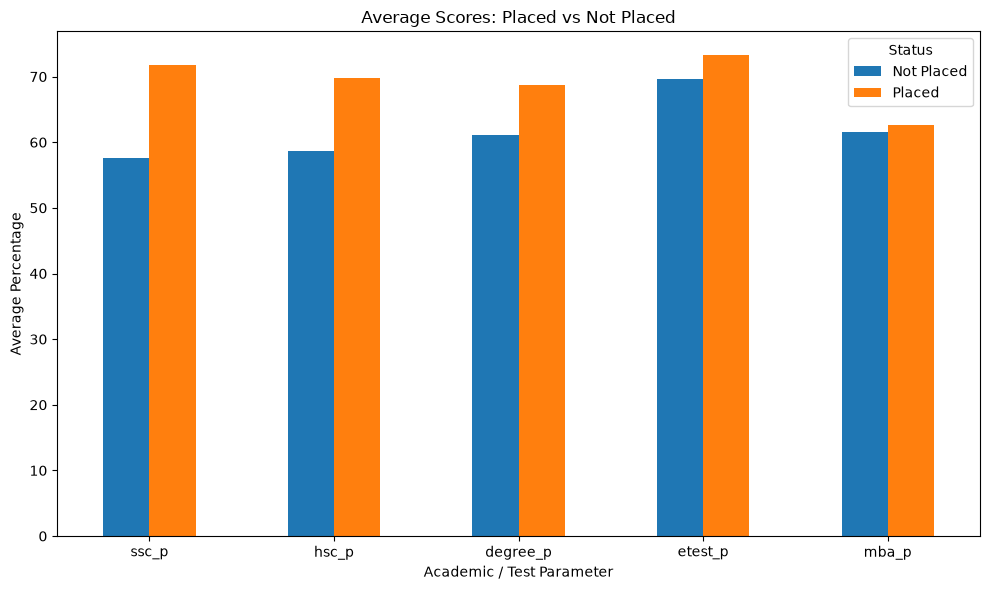

status,Not Placed,Placed
ssc_p,57.54,71.72
hsc_p,58.60,69.84
degree_p,61.13,68.72
etest_p,69.59,73.24
mba_p,61.61,62.58


In [16]:
score_cols = ["ssc_p","hsc_p","degree_p","etest_p","mba_p"]
status_means = dataset.groupby("status")[score_cols].mean().T

ax = status_means.plot(kind="bar", figsize=(10,6))
plt.title("Average Scores: Placed vs Not Placed")
plt.ylabel("Average Percentage")
plt.xlabel("Academic / Test Parameter")
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.tight_layout()
plt.show()

display(status_means.round(2))

**Graph explanation:** Placed students have higher average SSC, HSC and degree percentages than not-placed students. The difference is smaller for MBA percentage. This graph suggests that earlier academic performance is strongly associated with placement outcome in this dataset, although the graph alone does not establish causation.

# Final Summary

1. No NaN values remain in the supplied CSV; not-placed salaries are represented as zero.
2. **67** students are not placed.
3. Non-placement is associated with lower academic averages, no work experience, and specialization differences.
4. Salary vs MBA percentage correlation: **0.1414**, weak positive.
5. Among placed students, **Mkt&HR** has the lower average salary.
6. **3** students earn above ₹500,000.
7. ANOVA (`etest_p` vs `mba_p`): **Reject H₀**.
8. Sci&Tech vs Mkt&HR salary comparison: **Reject H₀** under the stated interpretation.
9. Salary standardized using Z-score.
10. Normal-model probability for ₹700k–₹900k: about **0.0414%**.
11. Sci&Tech paired test (`etest_p` vs `mba_p`): **Reject H₀**.
12. `ssc_p` is the numeric parameter most correlated with salary: **r ≈ 0.5585**.
13. The graph shows clear placement-group differences especially in SSC, HSC and degree averages.
